(38, 7)
(38,)
[[ 1.    0.27  0.39  0.5   0.57  0.51  0.41]
 [ 0.27  1.    0.13  0.5   0.57  0.69 -0.01]
 [ 0.39  0.13  1.    0.67  0.42  0.43  0.77]
 [ 0.5   0.5   0.67  1.    0.72  0.61  0.61]
 [ 0.57  0.57  0.42  0.72  1.    0.57  0.38]
 [ 0.51  0.69  0.43  0.61  0.57  1.    0.23]
 [ 0.41 -0.01  0.77  0.61  0.38  0.23  1.  ]]


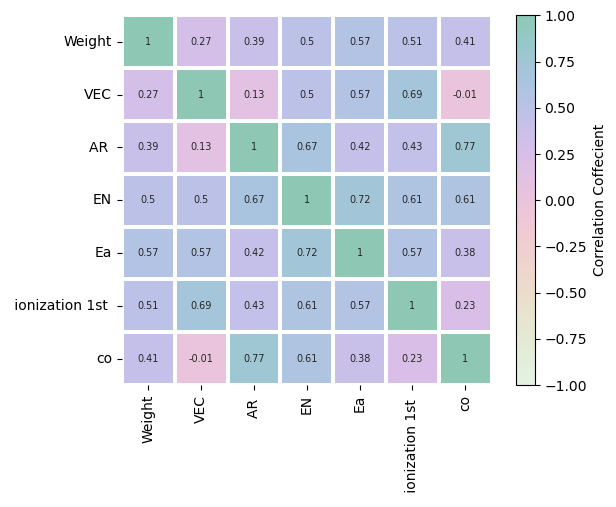

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from modules import *
import sys
import math
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.feature_selection import SelectKBest
from scipy.stats import pearsonr


File = 'y-y^(svr_fps)'   # 这一块直接把沸点删除,用 WT-10 中 SVR_FPS的数值和原始目标值做差值（原始-svr_fps），第一次差值做目标值
X,y= sub_data(File)
X,y= pre_data(X,y)
# X=np.delete(X,[6],axis=1)
X=X[:38,:]
y=y[:38]
print(X.shape)
print(y.shape)

m,n=X.shape
score_matrix0=[]
score_matrix=[]
for i in range(n):
    for j in range(n):
      score_matrix0 += [pearsonr(X[:,i],X[:,j])[0]]
for i in score_matrix0:
    if abs(i) < 0.01:
       score_matrix += [0.00]
    else:
       score_matrix += [round(i,2)]     #四舍五入，保留两位小数
score_matrix = np.array(score_matrix).reshape(n,n)
print(score_matrix)          # 输出矩阵
#d1=pd.DataFrame(score_matrix,index=['ave_elec_surf','ave_rad_surf','ave_elec_sub','ave_rad_sub','ave_elec_ad','ave_rad_ad','ave_elec_site','ave_rad_site','typ_site','typ_2'],columns=['ave_elec_surf','ave_rad_surf','ave_elec_sub','ave_rad_sub','ave_elec_ad','ave_rad_ad','ave_elec_site','ave_rad_site','typ_site','typ_2'])
d1=pd.DataFrame(score_matrix,index=['Weight','VEC','AR ','EN','Ea',' ionization 1st ','co'],columns=['Weight','VEC','AR ','EN','Ea',' ionization 1st ','co'])


import matplotlib.pyplot as plt
import seaborn as sns   
### 1st

#sns.set(font_scale=0.8)
#plt.rc('font',family='Time New Roman',size=12)
#plt.rc('font',size=10)

# cmap = sns.cubehelix_palette(start = 1.5, rot = 3, gamma=0.8, as_cmap = True)  #色卡的设置  暖色调
cmap = sns.cubehelix_palette(start = 1.5, rot = 2.5, gamma=0.5, as_cmap = True)  #色卡的设置   绿色调
#sns.heatmap(score_matrix,vmin=-1,vmax=1,square=True, linewidths=.5,center=True,annot=True,fmt='.2g',cmap='coolwarm')
#sns.heatmap(score_matrix,vmin=-1,vmax=1, square=True,linewidths=.5,annot=False,fmt='.2g',cmap='coolwarm')
#sh=sns.heatmap(d1,vmin=-1,vmax=1,square=True, linewidths=1.5,center=True,annot=True,fmt='.2g',cmap=cmap,cbar=False,annot_kws={"size":8})
sh=sns.heatmap(d1,vmin=-1,vmax=1,square=True, linewidths=1.5,center=True,annot=True,cmap=cmap,cbar=False,annot_kws={"size":7})
#sns.heatmap(d1,vmin=-1,vmax=1,square=True, linewidths=1.5,center=True,fmt='.2g',cmap=cmap,annot=True, annot_kws={'size':9,'weight':'bold', 'color':'blue'})
#sns.heatmap(score_matrix,vmin=-1,vmax=1,square=True, linewidths=.5,center=True,cmap=cmap)
sh.set_xticklabels(sh.get_xticklabels(),rotation=90)    #显示X轴的字体旋转

### colorbar sets ###
cb=sh.figure.colorbar(sh.collections[0])
cb.ax.tick_params(labelsize=10)
cb.set_label('Correlation Coffecient',fontsize=10)
plt.savefig('2-feat-EMFP.png',dpi=300,bbox_inches='tight')
plt.show()

In [3]:
from sklearn.ensemble import RandomForestRegressor
from modules import *
import sys
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

def plot_bar(feat,label,output=True,fname='feat_import',plt_prop=True):
   plt.figure(figsize=(12,12))
   feat1=list(reversed(feat))
   label1=list(reversed(label))
   plt.grid(axis='x',ls='--')
   ax=plt.gca()
   ax.spines['bottom'].set_linewidth(2)
   ax.spines['left'].set_linewidth(2)
   ax.spines['top'].set_linewidth(2)
   ax.spines['right'].set_linewidth(2)
   plt.axis([0,0.6,-1,7])  #此处y轴的参数范围修改
   #plt.yticks(rotation=30)
   #plt.barh(range(len(feat1)),feat1,color='rgb',tick_label=label1)
   #plt.barh(range(len(feat1)),feat1,tick_label=label1,fc='r',ec='b')
   plt.xticks(fontsize=18)
   plt.yticks(fontsize=18)
   #plt.grid()
   plt.xlabel(u'Feature Importance',fontsize=20)
   plt.ylabel(u'Features',fontsize=20)
   # plt.barh(range(len(feat1)),feat1,tick_label=label1,fc='red',alpha=0.75)  # 红色1.0
   plt.barh(range(len(feat1)),feat1,tick_label=label1,fc='green',alpha=0.6)   #绿色2.0
   for xx,yy in zip(range(len(feat1)),feat1):
      print(xx,yy)
      plt.text(yy+0.02,xx,round(yy,3),ha='center',va='center',fontsize=18)
   if output:
      plt.savefig(f'{fname}.png',dpi=300,bbox_inches='tight')
   if plt_prop:
      plt.show()

[0.13280921 0.34670621 0.11498545 0.0893583  0.19153191 0.08820735
 0.03640158]
0 0.03640157521370817
1 0.08820734709848155
2 0.19153190905125878
3 0.08935829528468885
4 0.1149854537542457
5 0.3467062131147833
6 0.1328092064828335


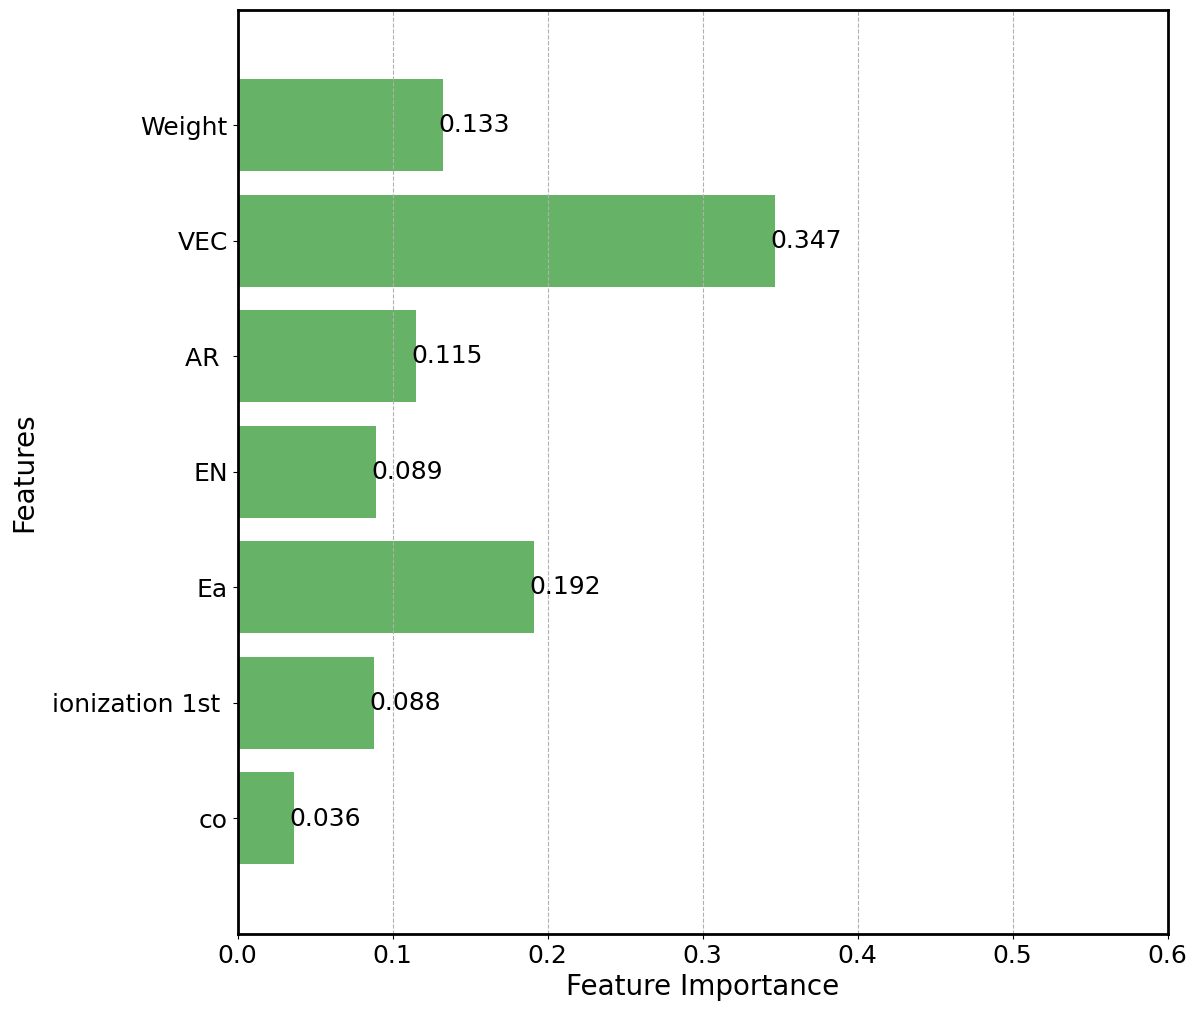

In [4]:
from sklearn.model_selection import train_test_split
if __name__ == '__main__':

 File = 'y-y^(svr_fps)'
 X,y= sub_data(File)
 X,y= pre_data(X,y)

 X=X[:38,:]
 y=y[:38]
#typ=sys.argv[1]
 typ='GBR'
 if typ == 'RFR':
   X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
   #print(len(X_train),len(X_test))
   regr = RandomForestRegressor(n_estimators=100,max_depth=5, random_state=0,oob_score=True)
   #parameters = {'max_depth':[5,8,10,15]}
   #regr=GridSearchCV(RFR,param_grid=parameters)
   regr.fit(X_train, y_train)
   #print(regr.best_params_)
   #print(regr.best_score_ )
   #print(regr.cv_results_)
   #print(regr.best_index_)
   #print(regr.cv_results_['params'][regr.best_index_])
   y_pre1=regr.predict(X_train)
   y_pre2=regr.predict(X_test)
   #print(regr.base_estimator_)
   #print(regr.estimators_)
   #print(regr.n_features_,regr.n_outputs_)
   print(regr.feature_importances_)
   #print(regr.oob_score_)
   #print(regr.score(X,y))
   feat=regr.feature_importances_
   label=['Weight','VEC','AR ','EN','Ea',' ionization 1st ','co']
   plot_bar(feat,label,output=True,fname=f'{typ}_feat_import',plt_prop=True)
   
 elif typ == 'ETR':
   X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
   #print(len(X_train),len(X_test))
   regr = ExtraTreesRegressor(n_estimators=100, max_depth=3,random_state=0,bootstrap=True,oob_score=True)
   regr.fit(X_train, y_train)
   #parameters = {'max_depth':[5,6,7,8,9,10]}
   #regr=GridSearchCV(ETR,param_grid=parameters)
   #regr.fit(X_train, y_train)
   #print(regr.best_params_)
   #print(regr.best_score_ )
   y_pre1=regr.predict(X_train)
   y_pre2=regr.predict(X_test)  
   
   #print(regr.base_estimator_)
   #print(regr.estimators_)
   #print(regr.n_features_,regr.n_outputs_)
   print(regr.feature_importances_)
   #print(regr.oob_score_)
   #print(regr.score(X,y))
   #print(regr.score(X_train, y_train))
   #print(regr.score(X_test, y_test))
   feat=regr.feature_importances_
   label=['Weight','VEC','AR ','EN','Ea',' ionization 1st ','co']
   plot_bar(feat,label,output=True,fname=f'{typ}_feat_import',plt_prop=True)

 elif typ == 'GBR':
   X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
   #print(len(X_train),len(X_test))
   regr = GradientBoostingRegressor(n_estimators=100,max_depth=2,learning_rate=0.1,random_state=0)
   #parameters = {'max_depth':[1,2,3,4,5,6,7,8,9,10],'learning_rate':[1,0.1,0.001,1E-4,1E-5,1E-6]}
   #regr=GridSearchCV(GBR,param_grid=parameters)
   regr.fit(X_train, y_train)
   #print(regr.best_params_)
   #print(regr.best_score_ )
   y_pre1=regr.predict(X_train)
   y_pre2=regr.predict(X_test)
   #print(regr.n_features_,regr.n_outputs_)
   print(regr.feature_importances_) 
   #print(regr.score(X_train, y_train))
   #print(regr.score(X_test, y_test))
   #print(regr.train_score_[100]) 
   feat=regr.feature_importances_
   label=['Weight','VEC','AR ','EN','Ea',' ionization 1st ','co']
   plot_bar(feat,label,output=True,fname=f'3-{typ}_feat_import',plt_prop=True)


去除内聚能，剩下几个继续模型训练